In [1]:
import pickle
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm
import numpy as np
import seaborn as sns

# Load prepared dataframes from pickle files
data_path = "../data_processed/"

with open(data_path + "session_data_prepared.pkl", "rb") as f:
    merged_df = pickle.load(f)

print("DataFrames loaded successfully:")
print(f"  merged_df shape: {merged_df.shape}")

DataFrames loaded successfully:
  merged_df shape: (65006, 27)


# Cluster Analysis

To conduct a clustering of the registered users, we first need to extract all session with a registered user and store these instances in a new variable

In [2]:
registered_users_df = merged_df[merged_df['isRegisteredUser'] == True].copy()

# Cyclic encoding of hour for correct circular averaging
registered_users_df['hour_sin'] = np.sin(2 * np.pi * registered_users_df['hour'] / 24)
registered_users_df['hour_cos'] = np.cos(2 * np.pi * registered_users_df['hour'] / 24)

In [3]:
print(f"Total sessions in merged_df: {len(merged_df)}")
print(f"Sessions from registered users: {len(registered_users_df)}")
print(f"Unique registered users to cluster: {registered_users_df['userID'].nunique()}")

Total sessions in merged_df: 65006
Sessions from registered users: 47815
Unique registered users to cluster: 1006


In [4]:
registered_users_df['siteID'].dtype
registered_users_df['siteID_numeric'] = (registered_users_df['siteID'] == '1').astype(int)

In [5]:
registered_users_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47815 entries, 2 to 65005
Data columns (total 30 columns):
 #   Column              Non-Null Count  Dtype                              
---  ------              --------------  -----                              
 0   id                  47815 non-null  object                             
 1   connectionTime      47815 non-null  datetime64[ns, America/Los_Angeles]
 2   disconnectTime      47815 non-null  datetime64[ns, America/Los_Angeles]
 3   doneChargingTime    47815 non-null  datetime64[ns, America/Los_Angeles]
 4   kWhDelivered        47815 non-null  float64                            
 5   sessionID           47815 non-null  object                             
 6   siteID              47815 non-null  object                             
 7   spaceID             47815 non-null  object                             
 8   stationID           47815 non-null  object                             
 9   userID              47815 non-null  object  

In [6]:
# Aggregating statistics to User Level
user_profiles = registered_users_df.groupby('userID').agg(
    avg_energy=('kWhDelivered', 'mean'),
    std_energy=('kWhDelivered', 'std'),
    total_energy=('kWhDelivered', 'sum'),
    avg_kWh_req=('kWhRequested', 'mean'),
    frequency=('sessionID', 'count'),
    avg_duration=('session_duration', 'mean'),
    total_charging_duration=('charging_duration', 'sum'),
    avg_charging_duration=('charging_duration', 'mean'), 
    avg_hour_sin=('hour_sin', 'mean'),  # Cyclic mean instead of avg_start_hour
    avg_hour_cos=('hour_cos', 'mean'),  # Cyclic mean instead of avg_start_hour
    pct_weekend_sessions=('is_weekend', 'mean'),
    avg_minutes_available=('minutesAvailable', 'mean'),
    pct_site_1=('siteID_numeric', 'mean')
)


user_profiles['kWh_requested_delta'] = user_profiles['avg_kWh_req'] - user_profiles['avg_energy']
user_profiles['session_duration_delta'] = user_profiles['avg_duration'] - user_profiles['avg_charging_duration']

The kWh_requested_delta shows the difference between requested and received energy.
The session_duration_delta represents the average time between doneChargingTime and disconnectTime, which is called idle time in EV charging

In [7]:
user_profiles.head()

,avg_energy,std_energy,total_energy,avg_kWh_req,frequency,avg_duration,total_charging_duration,avg_charging_duration,avg_hour_sin,avg_hour_cos,pct_weekend_sessions,avg_minutes_available,pct_site_1,kWh_requested_delta,session_duration_delta
userID,,,,,,,,,,,,,,,
1.0,1.659000,NaN,1.659000,5.000000,1,1.404444,1.241111,1.241111,-0.258819,-0.965926,0.0,150.000000,0.0,3.341000,0.163333
17.0,1.471000,NaN,1.471000,13.840000,1,0.302222,0.300278,0.300278,-0.707107,-0.707107,1.0,72.000000,0.0,12.369000,0.001944
22.0,18.754998,8.609281,1087.789899,36.906034,58,6.354296,245.049722,4.224995,0.569341,-0.642777,0.0,462.034483,0.0,18.151036,2.129301
43.0,43.266000,NaN,43.266000,43.400000,1,8.282222,6.988333,6.988333,0.707107,-0.707107,1.0,469.000000,0.0,0.134000,1.293889
45.0,8.069000,NaN,8.069000,17.500000,1,3.551389,2.157500,2.157500,-0.965926,-0.258819,1.0,134.000000,0.0,9.431000,1.393889


In [8]:
user_profiles.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1006 entries, 1.0 to 19923.0
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   avg_energy               1006 non-null   float64
 1   std_energy               843 non-null    float64
 2   total_energy             1006 non-null   float64
 3   avg_kWh_req              1006 non-null   float64
 4   frequency                1006 non-null   int64  
 5   avg_duration             1006 non-null   float64
 6   total_charging_duration  1006 non-null   float64
 7   avg_charging_duration    1006 non-null   float64
 8   avg_hour_sin             1006 non-null   float64
 9   avg_hour_cos             1006 non-null   float64
 10  pct_weekend_sessions     1006 non-null   float64
 11  avg_minutes_available    1006 non-null   float64
 12  pct_site_1               1006 non-null   float64
 13  kWh_requested_delta      1006 non-null   float64
 14  session_duration_delta  

For the **std_energy_pct** we use the percentage of the standard deviation of delivered energy as absolute values can differ when the avg_energy is overall higher. For user who have only one session we filled the empty deviation with a 0. 

In [9]:
print(user_profiles['std_energy'].isna().sum())
# use a indicator fo user with only one session & fill std_energy NaN with median
user_profiles['std_energy_filled'] = user_profiles['std_energy'].fillna(0)

163


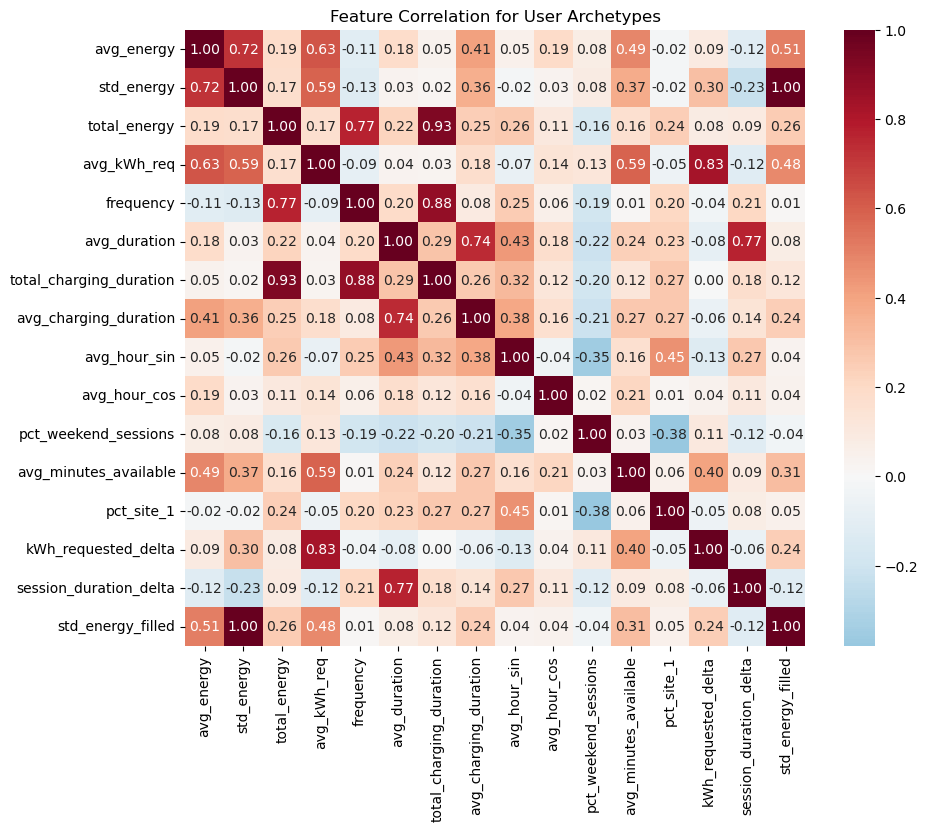

In [10]:
corr_matrix = user_profiles.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('Feature Correlation for User Archetypes')
plt.show()

We use a correlation matrix to identify redundant features before clustering. If two features are highly correlated —such as `avg_session_duration` and `avg_charging_duration` (0.74)— including both would effectively double their weight in the distance calculation, biasing the clusters.

The matrix also reveals unexpected relationships between variables. For instance, while we would intuitively expect a strong positive correlation between `avg_duration` and `avg_energy`, they show a surprisingly low correlation of only 0.18. This suggests that stay time is not a reliable predictor of energy delivered, indicating distinct user behaviors, which we will explore further in the following analysis.

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import pandas as pd

features_to_standardize = ['kWh_requested_delta', 'avg_energy', 
    'frequency','avg_duration',
     'avg_hour_sin', 'avg_hour_cos',
      'session_duration_delta']
features_to_passthrough = [] # if we want to include features such as 'pct_site_1' without scaling
cluster_features = features_to_standardize + features_to_passthrough

ct = ColumnTransformer([
    ('scaled_features', StandardScaler(), features_to_standardize),
    ('passthrough_features', 'passthrough', features_to_passthrough)
])

user_profiles_scaled_array = ct.fit_transform(user_profiles)

user_profiles_scaled = pd.DataFrame(
    user_profiles_scaled_array,
    columns=cluster_features,
    index=user_profiles.index
)

We choose the following features to cover many different dimensions which gives us better interpreting clusters and tried to leave out features with a high correlation between them.

* Energy and Demand
  * avg_energy
  * kWh_requested_delta
* Frequency and duration of use
  * frequency
  * avg_duration
* Temporal Behavior
  * avg_hour_sin, avg_hour_cos (cyclic encoding of average start hour to correctly handle the circular nature of time — e.g. a user charging at 23:00 and 01:00 should average to midnight, not noon)
* Charging Behavior/ Efficiency
  * session_duration_delta

In [12]:
print(user_profiles_scaled.shape)

(1006, 7)


In [13]:

outliers = (np.abs(user_profiles_scaled[[ 'kWh_requested_delta', 'avg_energy',
    'frequency','avg_duration',
    'avg_hour_sin', 'avg_hour_cos',
    'session_duration_delta']]) > 2).any(axis=1)
print(f"Number of users with atleast one extreme Feature (Z > 2): {outliers.sum()}")

Number of users with atleast one extreme Feature (Z > 2): 193


The features `kWh_requested_delta`, `avg_energy`, `frequency`, `avg_duration`, `avg_hour_sin`, `avg_hour_cos` and `session_duration_delta` contain outliers that could negatively impact the clustering process. To address this we, identify and remove outliers using the 2 sigma threshold, which has proven to improve the Silhouette Score later the best.

In [14]:
user_profiles_scaled = user_profiles_scaled[~outliers].copy()
user_profiles = user_profiles[~outliers].copy()

### Hyperparameter Tuning

We use two metrics to determine the optimal number of clusters for our GMM: the **Bayesian Information Criterion (BIC)** and the **Silhouette Score**.

* The **BIC** penalizes model complexity while rewarding goodness of fit. It is the natural model selection criterion for GMMs, analogous to the Elbow Method used for KMeans.
* The **Silhouette Score** is a model-agnostic metric that measures how well each data point fits within its assigned cluster relative to neighboring clusters. It can be applied to any clustering algorithm, including GMM, by using the hard cluster assignments from `predict()`.

### Cluster Alg implementation

#### We decided to use the GMM for soft clustering

c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory l

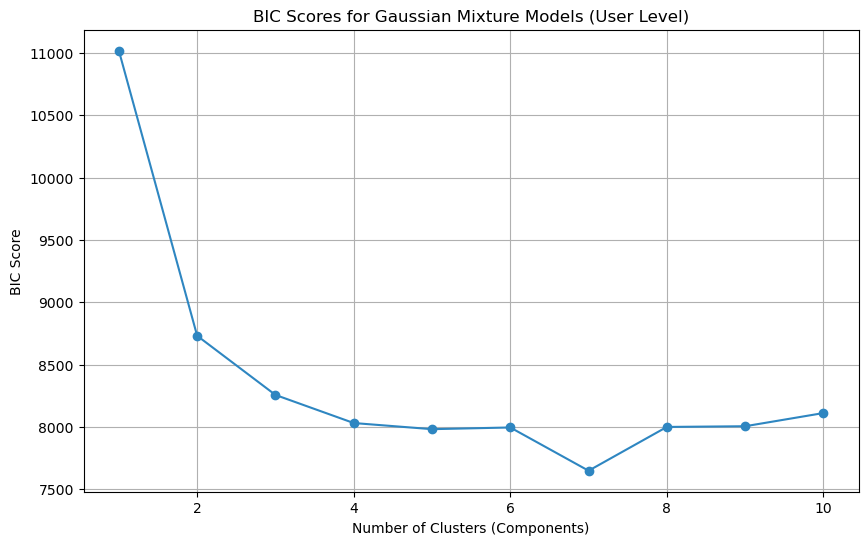

In [15]:
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture

# 1. BIC-Score Berechnung zur Bestimmung der optimalen Cluster-Anzahl
bic_scores = []
n_components_range = range(1, 11)  # Bei 1000 Usern reichen oft 1-10 Komponenten

for n_components in n_components_range:
    gmm = GaussianMixture(n_components=n_components, random_state=42)
    gmm.fit(user_profiles_scaled)
    bic_scores.append(gmm.bic(user_profiles_scaled))

# Plot BIC
plt.figure(figsize=(10, 6))
plt.plot(n_components_range, bic_scores, marker='o', color='#2E86C1')
plt.title('BIC Scores for Gaussian Mixture Models (User Level)')
plt.xlabel('Number of Clusters (Components)')
plt.ylabel('BIC Score')
plt.grid(True)
plt.show()

c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(
c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\clust

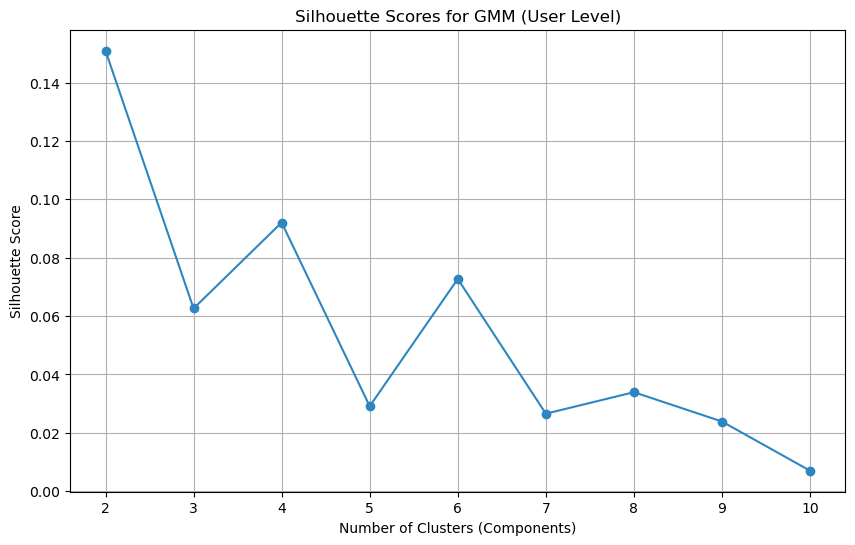

Best k by Silhouette: 2 (score: 0.1509)


In [16]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
sil_range = range(2, 11)  # Silhouette requires at least 2 clusters

for n in sil_range:
    gmm = GaussianMixture(n_components=n, random_state=42)
    labels = gmm.fit_predict(user_profiles_scaled)
    silhouette_scores.append(silhouette_score(user_profiles_scaled, labels))

plt.figure(figsize=(10, 6))
plt.plot(sil_range, silhouette_scores, marker='o', color='#2E86C1')
plt.title('Silhouette Scores for GMM (User Level)')
plt.xlabel('Number of Clusters (Components)')
plt.ylabel('Silhouette Score')
plt.grid(True)
plt.show()

print(f"Best k by Silhouette: {list(sil_range)[np.argmax(silhouette_scores)]} (score: {max(silhouette_scores):.4f})")

We decided to use **4 clusters** for our analysis based on the following reasoning:

* **BIC**: The BIC plot shows a steep decline from $k=1$ to $k=4$, after which the curve flattens into a plateau ($k=4$ to $k=6$). While $k=7$ achieves the global BIC minimum, the score rises again for $k=8$–$10$, suggesting instability and potential overfitting at higher component counts. The "elbow" of the BIC curve occurs at $k=4$, marking the point of diminishing returns.
* **Silhouette Score**: Among the tested values, $k=4$ achieves one of the highest Silhouette Scores, confirming good cluster separation and cohesion. Note that Silhouette Scores for GMM tend to be lower than for KMeans, since GMM allows elliptical, overlapping clusters — which the Euclidean-distance-based Silhouette metric penalizes. Therefore, the Silhouette Score is used here as a relative comparison between different $k$ values rather than as an absolute quality measure.
* **Interpretability**: The resulting four clusters produce clearly distinguishable user archetypes with strong feature contrasts, as confirmed by the heatmap analysis. Increasing to $k=5$ introduces clusters with overlapping profiles that are difficult to differentiate.

In [17]:
optimal_components = 4
best_gmm = GaussianMixture(n_components=optimal_components, random_state=42)
best_gmm.fit(user_profiles_scaled)
user_profiles['Clusters'] = best_gmm.predict(user_profiles_scaled)

c:\ProgramData\anaconda3\envs\aa_project_env\lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


In [18]:
# Convert cyclic hour features back to interpretable avg_start_hour for reporting
user_profiles['avg_start_hour'] = (
    np.arctan2(user_profiles['avg_hour_sin'], user_profiles['avg_hour_cos']) * 24 / (2 * np.pi)
) % 24

# Display features: replace avg_hour_sin & avg_hour_cos with a single readable avg_start_hour
display_features = ['kWh_requested_delta', 'avg_energy', 'frequency', 'avg_duration', 'avg_start_hour', 'session_duration_delta']

print("Cluster features (for model):", cluster_features)
print("Display features (for report):", display_features)

Cluster features (for model): ['kWh_requested_delta', 'avg_energy', 'frequency', 'avg_duration', 'avg_hour_sin', 'avg_hour_cos', 'session_duration_delta']
Display features (for report): ['kWh_requested_delta', 'avg_energy', 'frequency', 'avg_duration', 'avg_start_hour', 'session_duration_delta']


### Clustering Results Analysis

In [19]:
cluster_mapping = {
    0: 'Brief Infrequent Users', 
    1: 'Employees',
    2: 'Frequent Top-Ups',
    3: 'Occasional Whales',
}

user_profiles['Clusters_Name'] = user_profiles['Clusters'].map(cluster_mapping)

cluster_summary = user_profiles.groupby('Clusters_Name')[display_features].mean()

print("--- ARCHETYPE REPORT (Mean per cluster) ---")

print(cluster_summary.T) 

print("\nNumber of users per archetype:")
counts = user_profiles['Clusters_Name'].value_counts()
print(counts)

--- ARCHETYPE REPORT (Mean per cluster) ---
Clusters_Name           Brief Infrequent Users  Employees  Frequent Top-Ups  \
kWh_requested_delta                  14.201384   9.038271          5.940601   
avg_energy                           14.199925  14.992205          8.121254   
frequency                             4.631868  54.616667         59.362069   
avg_duration                          2.066985   7.682446          4.532704   
avg_start_hour                       13.343420   7.548966         12.494109   
session_duration_delta                0.001497   3.180612          1.897737   

Clusters_Name           Occasional Whales  
kWh_requested_delta             13.796754  
avg_energy                      16.605710  
frequency                       20.884793  
avg_duration                     4.364344  
avg_start_hour                  11.585117  
session_duration_delta           1.129733  

Number of users per archetype:
Clusters_Name
Employees                 240
Occasional Whales 

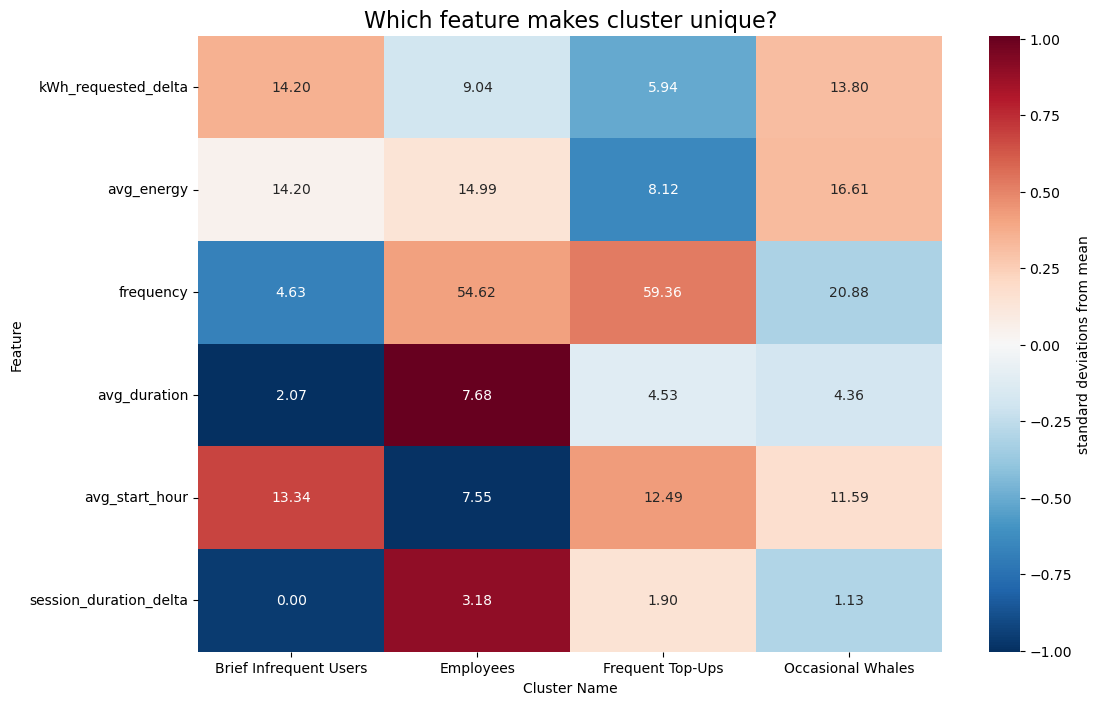

In [20]:
import seaborn as sns

cluster_summary = user_profiles.groupby('Clusters_Name')[display_features].mean()

# (Z-Score of Averages)
summary_scaled = (cluster_summary - user_profiles[display_features].mean()) / user_profiles[display_features].std()

plt.figure(figsize=(12, 8))
sns.heatmap(summary_scaled.T, 
            annot=cluster_summary.T,
            fmt=".2f", 
            cmap="RdBu_r", 
            center=0,
            cbar_kws={'label': 'standard deviations from mean'})

plt.title('Which feature makes cluster unique?', fontsize=16)
plt.xlabel('Cluster Name')
plt.ylabel('Feature')
plt.show()

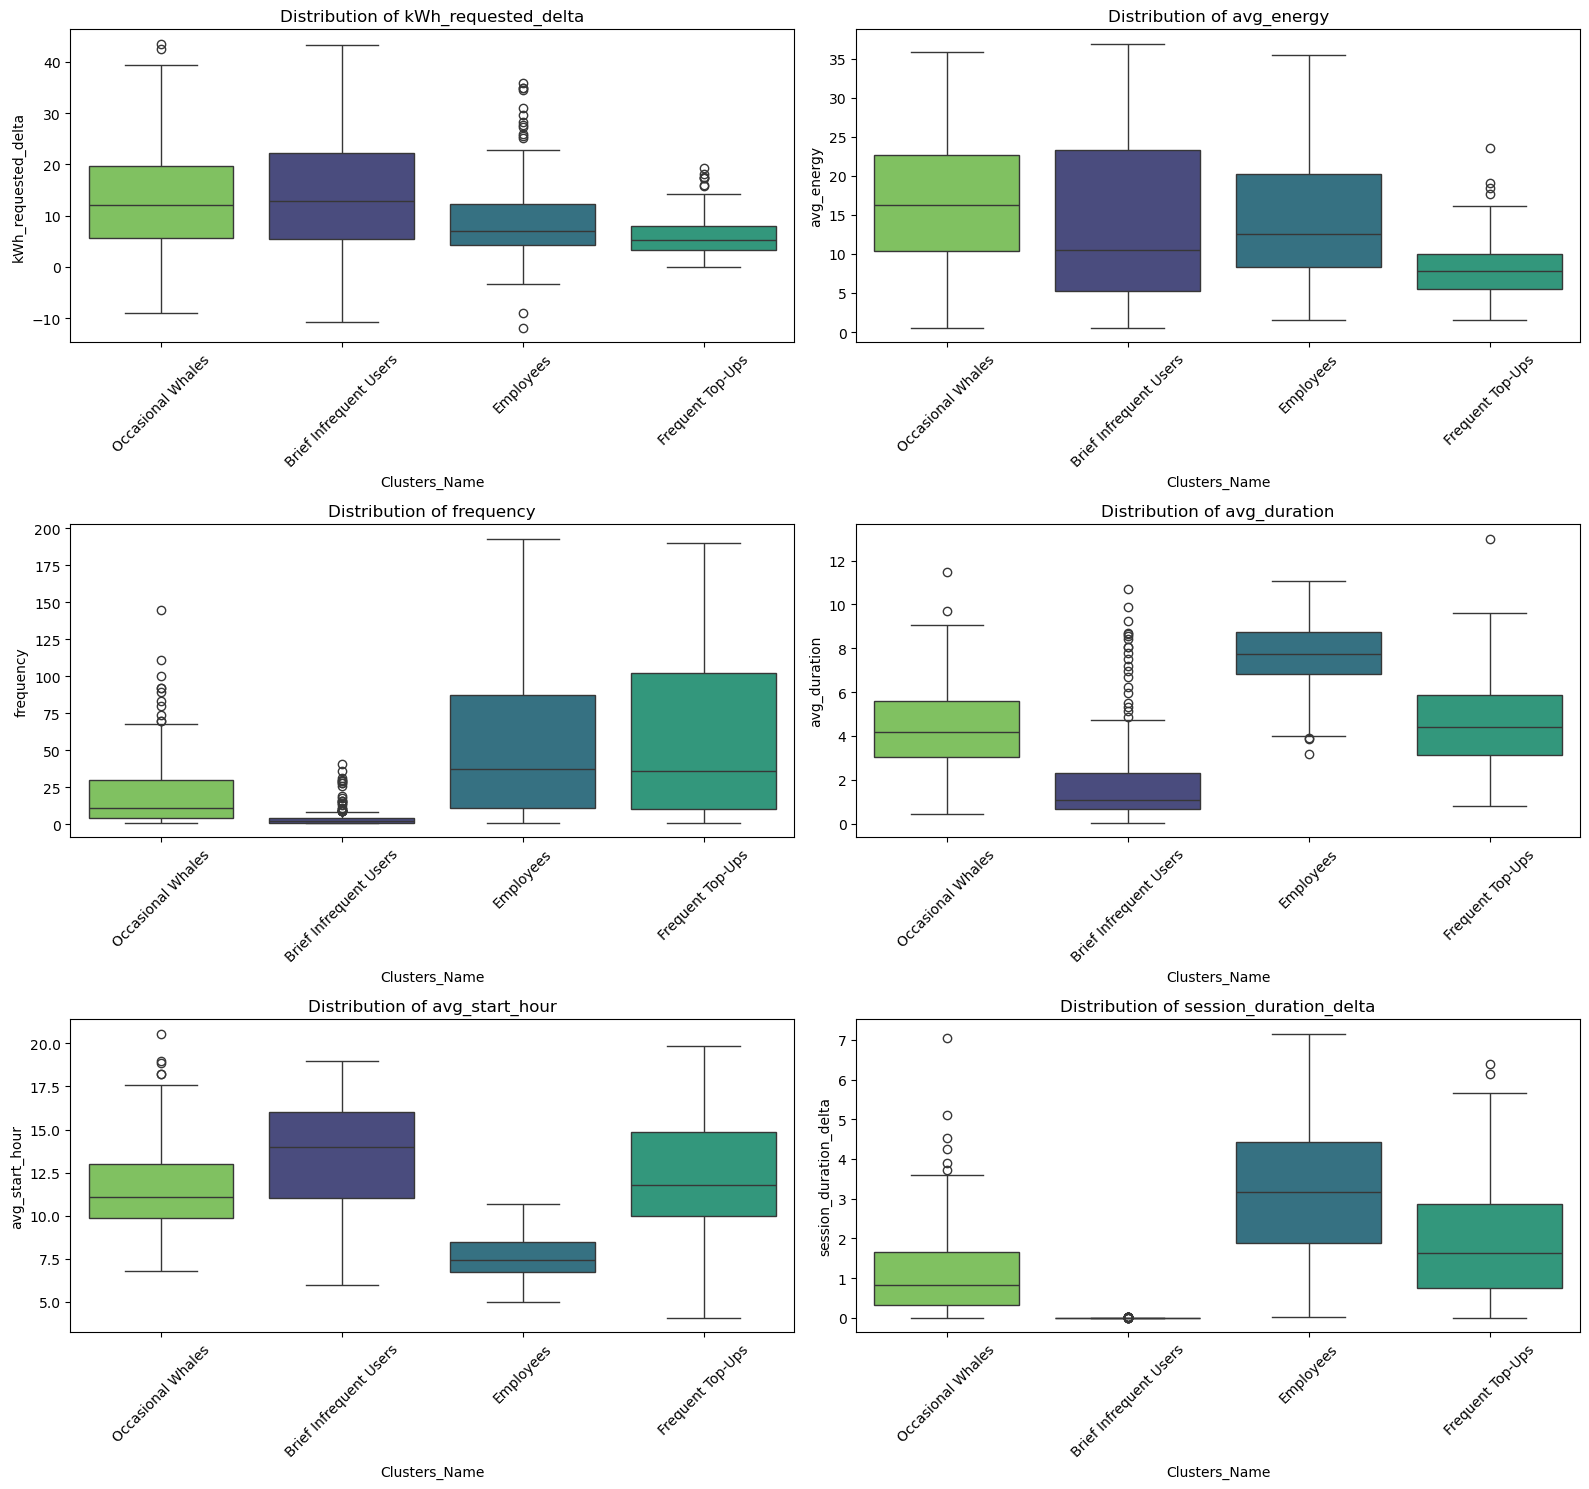

In [21]:
import math


num_features = len(display_features)
cols = 2
rows = math.ceil(num_features / cols)

fig, axes = plt.subplots(rows, cols, figsize=(16, 5 * rows))
axes = axes.flatten()

cluster_order = sorted(
    user_profiles['Clusters_Name'].unique(), 
)

for i, feature in enumerate(display_features):
    sns.boxplot(
        x='Clusters_Name', 
        y=feature, 
        data=user_profiles, 
        ax=axes[i], 
        palette='viridis', 
        hue='Clusters_Name', 
        hue_order=cluster_order,
        legend=False
    )
    axes[i].set_title(f'Distribution of {feature}')
    axes[i].tick_params(axis='x', labelrotation=45)

# Remove any empty subplots if num_features is odd
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

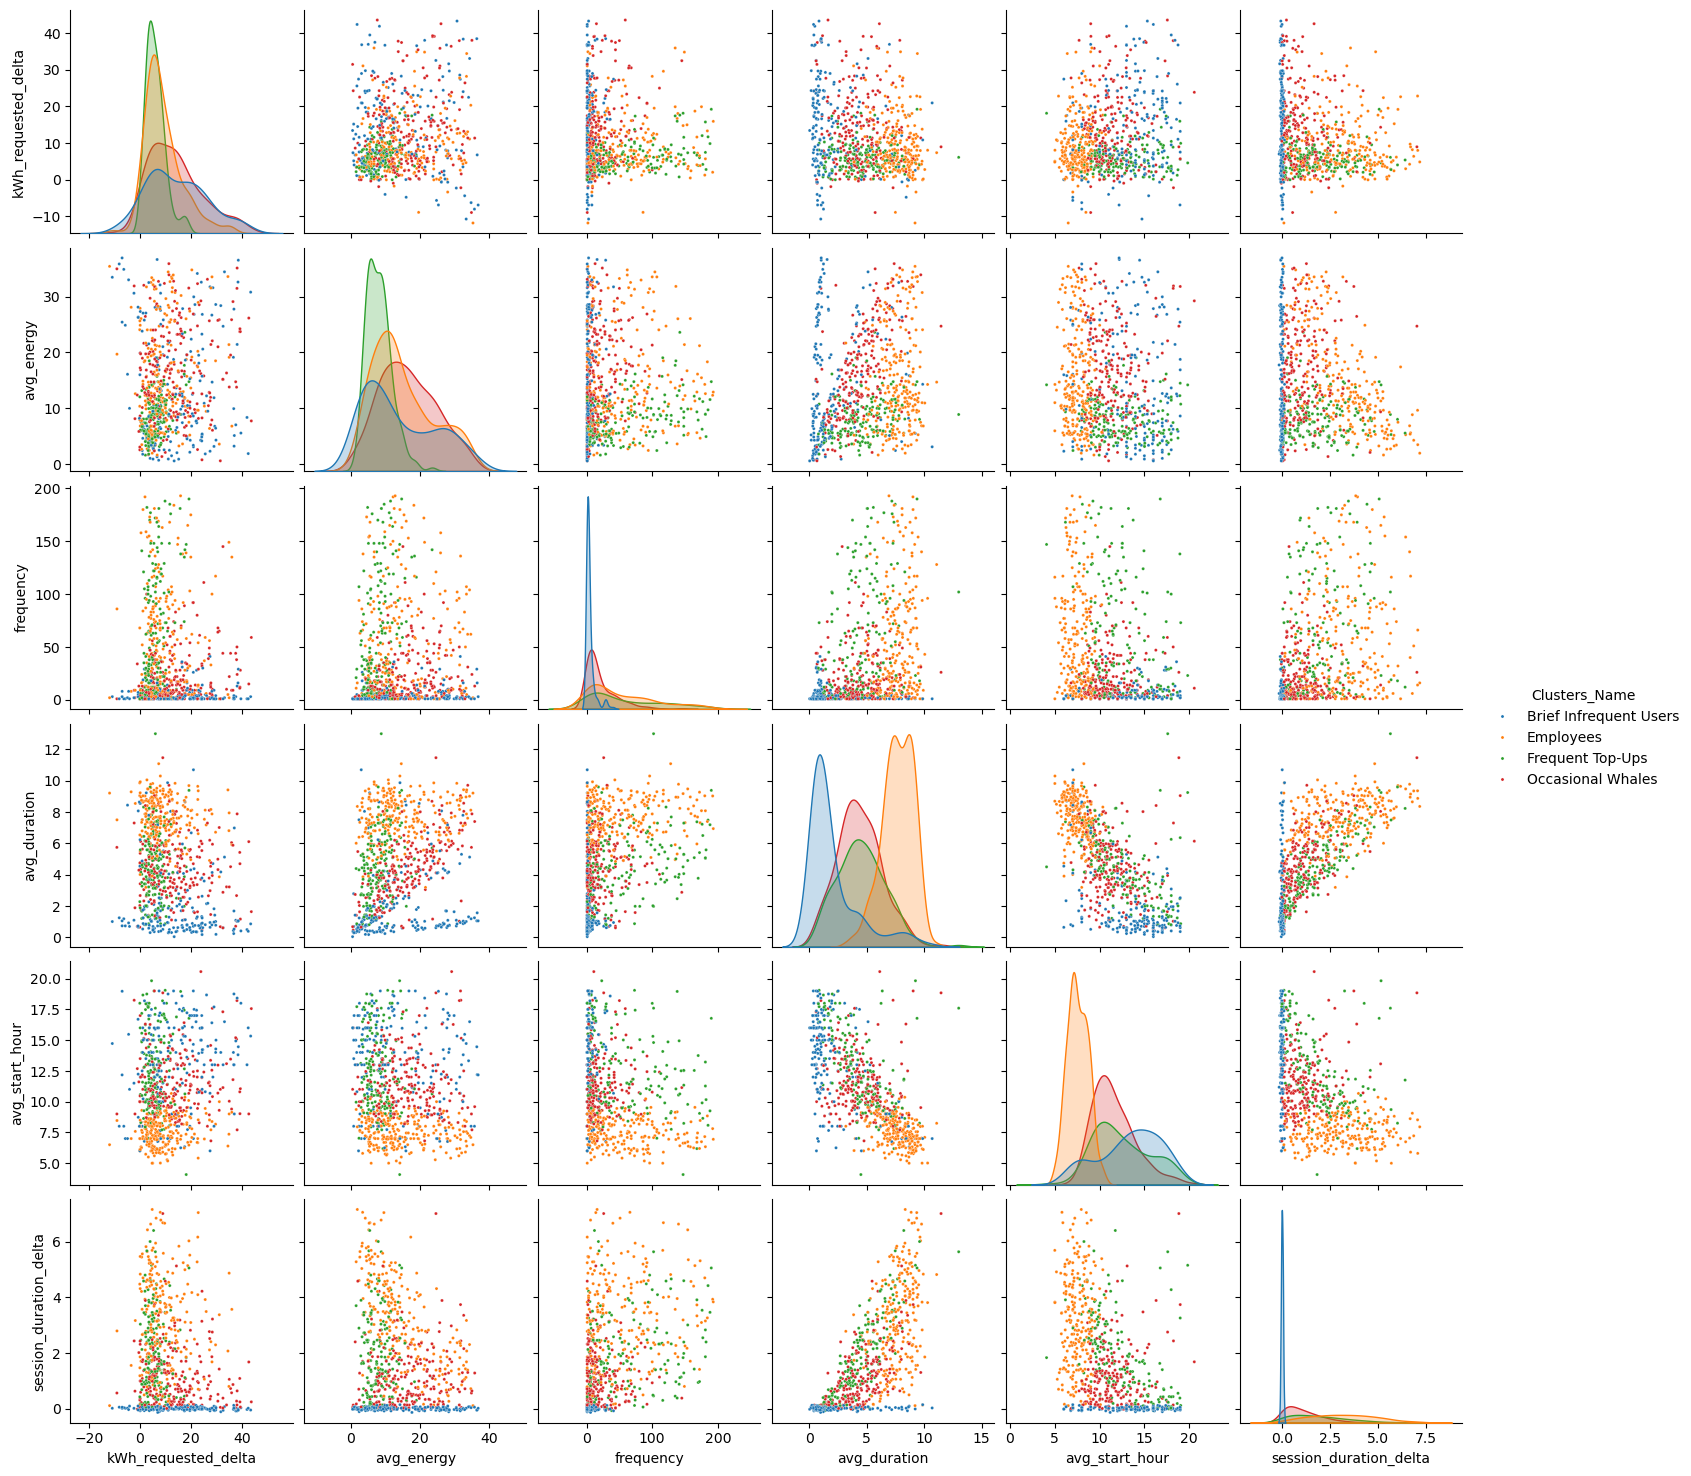

In [22]:
example_features = display_features
plot_df = user_profiles.copy()
plot_df['session_duration_delta'] = plot_df['session_duration_delta'] + np.random.normal(0, 0.05, len(plot_df))

hue_order = sorted(plot_df['Clusters_Name'].unique())
sns.pairplot(
    plot_df[example_features + ['Clusters_Name']], 
    diag_kind='kde', 
    hue='Clusters_Name', 
    hue_order=hue_order,
    plot_kws={'s':5}
    
)
plt.show()

* Cluster 1: Brief infrequent users
  * lowest frequency (4.63) and shortest session duration (2.07h)
  * highest kWh requested delta (14.20) => they request far more energy than they actually receive
  * afternoon start hour (13.34) and zero idle time (session_duration_delta = 0.00)
  * **=> occasional, time-constrained users who disconnect early; suited for pay-per-use models and onboarding campaigns**

* Cluster 2: Employees
  * very high frequency (54.62) with the longest session duration (7.68h)
  * earliest start hour (7.55) — consistent early-morning arrivals
  * highest idle time (session_duration_delta = 3.18h) => they stay plugged in well beyond charging completion
  * lowest kWh requested delta (9.04) with high energy delivery (14.99 kWh)
  * **=> heavy routine users who treat the station as a combined charging and parking facility; suited for workplace tariffs, parking-integrated pricing, and grid flexibility programs**

* Cluster 3: Frequent Top-Ups
  * highest frequency (59.36) — the most active user group
  * lowest energy per session (8.12 kWh) and lowest kWh requested delta (5.94)
  * midday start hour (12.49) with moderate idle time (1.90h)
  * **=> daily power users with low per-session demand; ideal for subscription models, loyalty programs, and reliable demand forecasting**

* Cluster 4: Occasional Whales
  * highest average energy delivery (16.61 kWh) with moderate frequency (20.88)
  * short session duration (4.36h) and low idle time (session_duration_delta = 1.13h)
  * late-morning start hour (11.59) with high kWh requested delta (13.80)
  * **=> energy-focused, efficient users who maximize charging per session with minimal idle time; suited for premium pricing tiers and high-power charger allocation**